# Week 4 — Statistics, Data Visualization & EDA

**Dataset:** Synthetic Online Retail Customer Purchases dataset (500+ records),
generated to include realistic messiness — missing values, duplicate rows,
outliers, and an inconsistent categorical value — so that cleaning and outlier
detection steps have real issues to solve.

**Columns:** `CustomerID`, `Age`, `Gender`, `City`, `Product_Category`,
`Quantity`, `Rating`, `Membership`, `Purchase_Amount`, `Purchase_Date`


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset.csv", parse_dates=["Purchase_Date"])
df.head()


,CustomerID,Age,Gender,City,Product_Category,Quantity,Rating,Membership,Purchase_Amount,Purchase_Date
0,1001,40.0,Female,Delhi,Electronics,2,5.0,No,4463.71,2024-01-01 00:00:00
1,1002,34.0,Female,Mumbai,Grocery,2,5.0,No,937.39,2024-01-01 17:00:00
2,1003,41.0,Male,Bengaluru,Clothing,2,3.0,Yes,1201.95,2024-01-02 10:00:00
3,1004,50.0,Female,Delhi,Books,3,4.0,No,889.61,2024-01-03 03:00:00
4,1005,33.0,Female,Delhi,Beauty,5,4.0,No,2281.47,2024-01-03 20:00:00


## Task 1: Statistical Analysis — Mean, Median & Mode

We calculate the central tendency of `Purchase_Amount`, the main numerical
variable of interest in this dataset.


In [25]:
mean_val = df["Purchase_Amount"].mean()
median_val = df["Purchase_Amount"].median()
mode_val = df["Purchase_Amount"].mode()[0]
print(f"Mean Purchase Amount:   {mean_val:.2f}")
print(f"Median Purchase Amount: {median_val:.2f}")
print(f"Mode Purchase Amount:   {mode_val:.2f}")

Mean Purchase Amount:   2739.25
Median Purchase Amount: 1366.12
Mode Purchase Amount:   50.00


**Interpretation:**
- The **mean** gives the average amount spent per purchase across all customers, but it
  is sensitive to the extreme high-value purchases (outliers) present in the data, so it
  is pulled higher than a "typical" purchase.
- The **median** represents the middle value when all purchases are sorted, and is a more
  robust measure of the "typical" purchase amount since it ignores the effect of outliers.
- The **mode** is the most frequently occurring purchase amount; with continuous currency
  data it is less meaningful here (values rarely repeat exactly), which itself is a useful
  observation about the nature of the variable.


## Task 2: Variance & Standard Deviation

In [44]:
variance_val = df["Purchase_Amount"].var()
std_val = df["Purchase_Amount"].std()
print(f"Variance of Purchase Amount:           {variance_val:.2f}")
print(f"Standard Deviation of Purchase Amount: {std_val:.2f}")

Variance of Purchase Amount:           12124888.16
Standard Deviation of Purchase Amount: 3482.08


**Interpretation:** The standard deviation shows how much individual purchase
amounts typically deviate from the mean. A high standard deviation relative to the
mean (here, roughly on the same order as the mean itself) indicates that purchase
amounts vary widely across customers — driven by the mix of low-cost categories
(Grocery, Books) and high-cost categories (Electronics), plus a handful of outliers.


## Task 3: Correlation & Probability Basics

### Correlation
We check the relationship between `Quantity` purchased and `Purchase_Amount`.


In [45]:
correlation = df["Quantity"].corr(df["Purchase_Amount"])
print(f"Correlation between Quantity and Purchase_Amount: {correlation:.3f}")
if correlation > 0.3:
    relationship = "positive"
elif correlation < -0.3:
    relationship = "negative"
else:
    relationship = "weak / negligible"
print(f"Relationship type: {relationship}")

Correlation between Quantity and Purchase_Amount: 0.353
Relationship type: positive


### Probability
**Real-world example:** What is the probability that a randomly selected customer
in this dataset is a member (`Membership == "Yes"`) AND purchased from the
Electronics category?


In [46]:
p_member = (df["Membership"] == "Yes").mean()
p_electronics = (df["Product_Category"] == "Electronics").mean()
p_member_and_electronics = ((df["Membership"] == "Yes") & (df["Product_Category"] == "Electronics")).mean()
print(f"P(Member):                       {p_member:.3f}")
print(f"P(Electronics purchase):         {p_electronics:.3f}")
print(f"P(Member AND Electronics):       {p_member_and_electronics:.3f}")

P(Member):                       0.351
P(Electronics purchase):         0.259
P(Member AND Electronics):       0.082


**Interpretation:** The correlation value tells us whether buying more units
tends to go with spending more money overall (expected, since amount scales with
quantity). The probability calculation shows how likely a random customer is to be
both a paying member and an Electronics shopper — useful for estimating how many
customers a "Members-only Electronics sale" campaign would realistically reach.


## Task 4: Outlier Detection

We use the **IQR (Interquartile Range) method** on `Purchase_Amount` and `Age`.


In [47]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper
amount_outliers, low_a, up_a = detect_outliers_iqr(df["Purchase_Amount"])
age_outliers, low_g, up_g = detect_outliers_iqr(df["Age"].dropna())
print(f"Purchase_Amount valid range: [{low_a:.2f}, {up_a:.2f}]")
print(f"Number of Purchase_Amount outliers: {len(amount_outliers)}")
print(amount_outliers.sort_values(ascending=False).head(10))
print(f"\nAge valid range: [{low_g:.2f}, {up_g:.2f}]")
print(f"Number of Age outliers: {len(age_outliers)}")
print(age_outliers.sort_values(ascending=False))

Purchase_Amount valid range: [-2055.74, 5403.39]
Number of Purchase_Amount outliers: 89
38     36394.40
482    11929.71
488    11917.81
392    11696.47
194    11588.31
329    11577.22
311    11562.19
159    11549.64
135    11529.69
342    11523.75
Name: Purchase_Amount, dtype: float64

Age valid range: [8.50, 60.50]
Number of Age outliers: 7
273    101.0
220     98.0
265     95.0
209     74.0
478     66.0
179     62.0
262      3.0
Name: Age, dtype: float64


**How outliers affect analysis:** Outliers can distort the mean, inflate
variance/standard deviation, weaken correlation estimates, and mislead models
trained on this data (e.g. a regression model would try to "fit" the extreme
Purchase_Amount values, skewing predictions for typical customers).


## Task 5: Matplotlib Visualizations

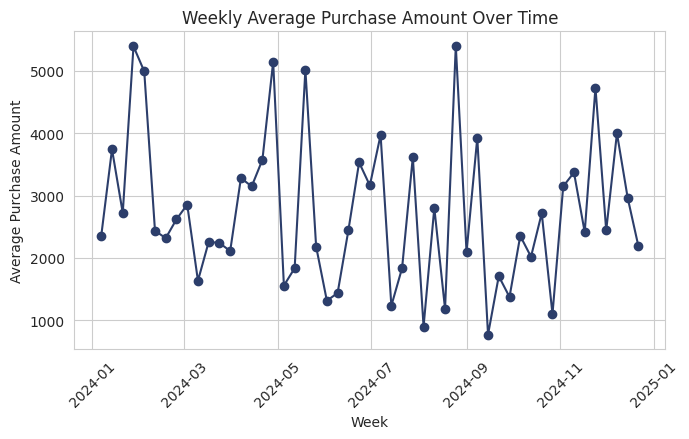

In [48]:
monthly = df.set_index("Purchase_Date").resample("W")["Purchase_Amount"].mean()
plt.figure()
plt.plot(monthly.index, monthly.values, marker="o", color="#2c3e6b")
plt.title("Weekly Average Purchase Amount Over Time")
plt.xlabel("Week")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Explanation:** This line chart tracks how the average amount spent per purchase changes week over week, useful for spotting seasonal spikes or dips in spending.

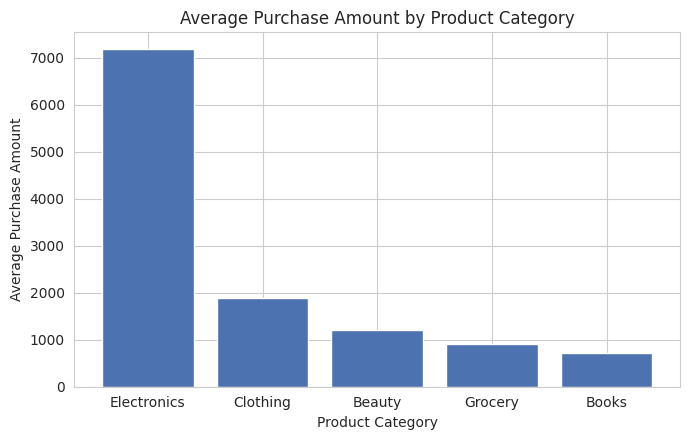

In [49]:
cat_avg = df.groupby("Product_Category")["Purchase_Amount"].mean().sort_values(ascending=False)
plt.figure()
plt.bar(cat_avg.index, cat_avg.values, color="#4c72b0")
plt.title("Average Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase Amount")
plt.tight_layout()
plt.show()

**Explanation:** This bar chart compares average spend across categories, clearly showing Electronics as the highest-value category, consistent with typical unit prices in that segment.

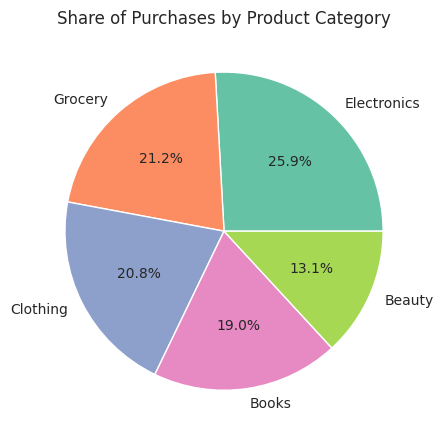

In [50]:
cat_counts = df["Product_Category"].value_counts()
plt.figure()
plt.pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2"))
plt.title("Share of Purchases by Product Category")
plt.tight_layout()
plt.show()

**Explanation:** This pie chart shows what proportion of total purchases each product category accounts for, highlighting Electronics and Clothing as the largest segments.

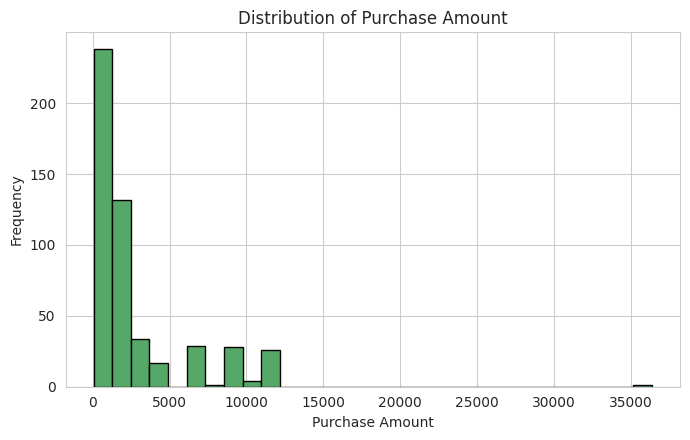

In [51]:
plt.figure()
plt.hist(df["Purchase_Amount"], bins=30, color="#55a868", edgecolor="black")
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Explanation:** The histogram shows Purchase_Amount is right-skewed - most purchases cluster at lower amounts, with a long tail from higher-value Electronics purchases and the injected outliers.

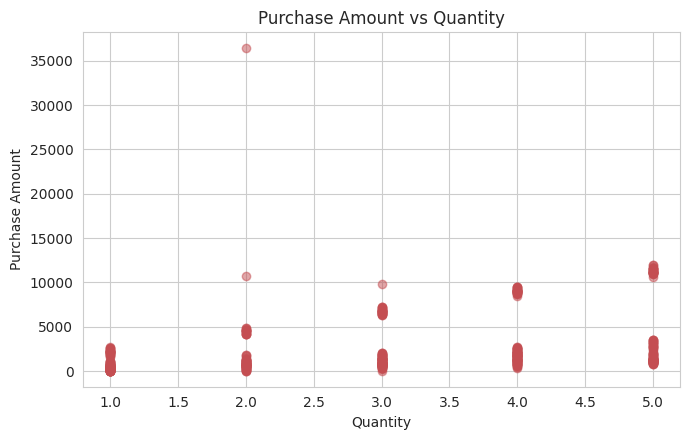

In [52]:
plt.figure()
plt.scatter(df["Quantity"], df["Purchase_Amount"], alpha=0.5, color="#c44e52")
plt.title("Purchase Amount vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Purchase Amount")
plt.tight_layout()
plt.show()

**Explanation:** The scatter plot visualizes the relationship measured in Task 3 — points trend upward as quantity increases, confirming the positive correlation between units bought and amount spent.
#Task 6: Seaborn Visualizations

/tmp/ipykernel_1720/2530165210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Product_Category",


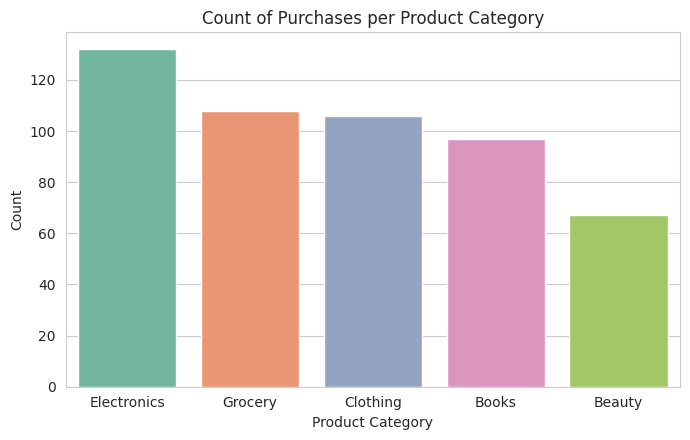

In [53]:
plt.figure()
sns.countplot(data=df, x="Product_Category",
              order=df["Product_Category"].value_counts().index, palette="Set2")
plt.title("Count of Purchases per Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1720/1115043509.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Product_Category", y="Purchase_Amount", palette="Set3")


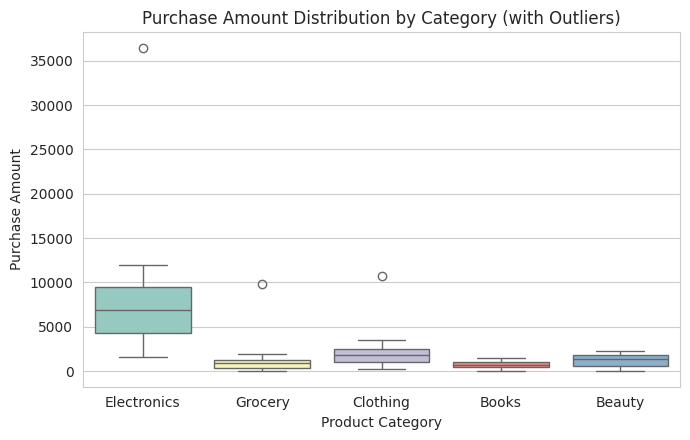

In [54]:
plt.figure()
sns.boxplot(data=df, x="Product_Category", y="Purchase_Amount", palette="Set3")
plt.title("Purchase Amount Distribution by Category (with Outliers)")
plt.xlabel("Product Category")
plt.ylabel("Purchase Amount")
plt.tight_layout()
plt.show()

**Explanation:** The box plot exposes the spread and outliers within each category individually - Electronics shows the widest spread and the most extreme high-value outliers, matching Task 4's findings.

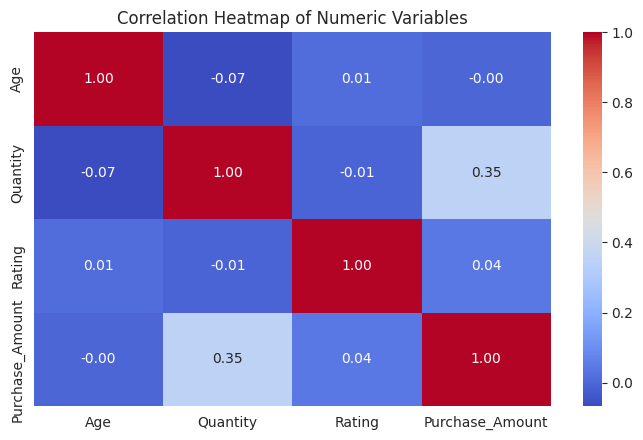

In [55]:
plt.figure()
numeric_cols = df[["Age", "Quantity", "Rating", "Purchase_Amount"]]
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

**Explanation:** The heatmap gives a full view of pairwise correlations at once - `Quantity` and `Purchase_Amount` show the strongest relationship, while `Age` and `Rating` are essentially uncorrelated with spending.

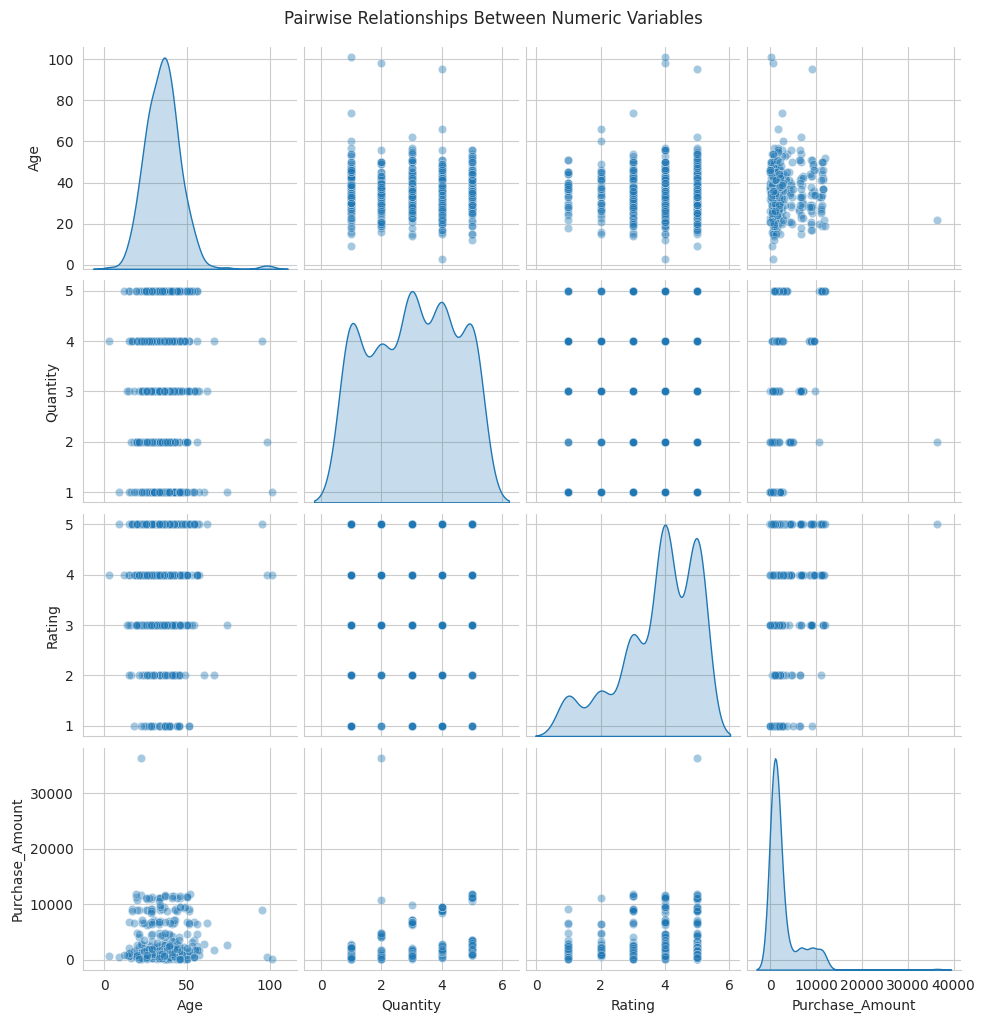

In [56]:
pair_sample = df[["Age", "Quantity", "Rating", "Purchase_Amount"]].dropna()
sns.pairplot(pair_sample, diag_kind="kde", plot_kws={"alpha": 0.4})
plt.suptitle("Pairwise Relationships Between Numeric Variables", y=1.02)
plt.show()

**Explanation:** The pair plot lays out every numeric variable against every other, making it easy to spot the Quantity-vs-Purchase_Amount trend visually alongside the distribution (diagonal) of each variable.
## Task 7: EDA — Data Inspection & Cleaning
### Data Inspection (Before Cleaning)

In [57]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nStatistical summary:\n", df.describe(include="all").T)

Shape (rows, columns): (510, 10)

Column names: ['CustomerID', 'Age', 'Gender', 'City', 'Product_Category', 'Quantity', 'Rating', 'Membership', 'Purchase_Amount', 'Purchase_Date']

Data types:
 CustomerID                   int64
Age                        float64
Gender                      object
City                        object
Product_Category            object
Quantity                     int64
Rating                     float64
Membership                  object
Purchase_Amount            float64
Purchase_Date       datetime64[ns]
dtype: object

Statistical summary:
                   count unique          top freq                 mean  \
CustomerID        510.0    NaN          NaN  NaN          1250.317647   
Age               491.0    NaN          NaN  NaN            35.443992   
Gender              510      3         Male  259                  NaN   
City                510      5      Chennai  114                  NaN   
Product_Category    510      5  Electronics  132      

### Data Cleaning

In [58]:
print("Missing values per column (BEFORE cleaning):")
print(df.isnull().sum())
print("\nDuplicate rows (BEFORE cleaning):", df.duplicated().sum())
print("\nUnique Gender values (BEFORE cleaning):", df["Gender"].unique())

Missing values per column (BEFORE cleaning):
CustomerID           0
Age                 19
Gender               0
City                 0
Product_Category     0
Quantity             0
Rating              24
Membership           0
Purchase_Amount      0
Purchase_Date        0
dtype: int64

Duplicate rows (BEFORE cleaning): 10

Unique Gender values (BEFORE cleaning): ['Female' 'Male' 'male ']


In [59]:
df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Rating"] = df_clean["Rating"].fillna(df_clean["Rating"].median())
df_clean = df_clean.drop_duplicates()
df_clean["Gender"] = df_clean["Gender"].str.strip().str.title()
print("Missing values per column (AFTER cleaning):")
print(df_clean.isnull().sum())
print("\nDuplicate rows (AFTER cleaning):", df_clean.duplicated().sum())
print("\nUnique Gender values (AFTER cleaning):", df_clean["Gender"].unique())
print("\nShape AFTER cleaning:", df_clean.shape)

Missing values per column (AFTER cleaning):
CustomerID          0
Age                 0
Gender              0
City                0
Product_Category    0
Quantity            0
Rating              0
Membership          0
Purchase_Amount     0
Purchase_Date       0
dtype: int64

Duplicate rows (AFTER cleaning): 0

Unique Gender values (AFTER cleaning): ['Female' 'Male']

Shape AFTER cleaning: (500, 10)


**Before vs after:** Missing `Age`/`Rating` values are imputed with the median (robust to outliers), the 10 duplicate rows are removed, and the inconsistent `"male "` entry is normalized to `"Male"`. Shape changes from the original messy dataset down to a clean, de-duplicated dataset.

## Task 8: EDA — Correlation & Insights

Correlation matrix (cleaned data):
                   Age  Quantity  Rating  Purchase_Amount
Age              1.000    -0.061   0.016           -0.001
Quantity        -0.061     1.000  -0.009            0.347
Rating           0.016    -0.009   1.000            0.042
Purchase_Amount -0.001     0.347   0.042            1.000


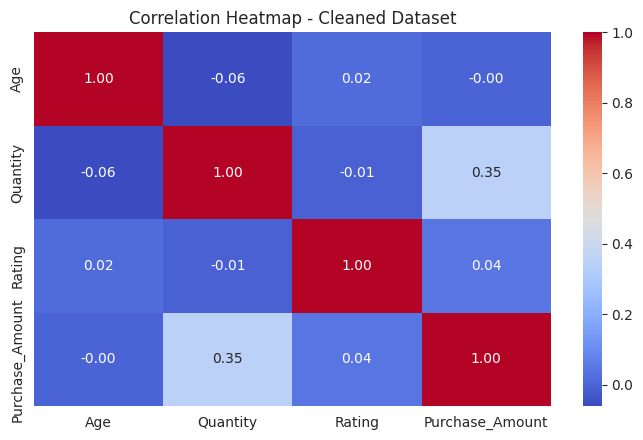

In [60]:
corr_matrix_clean = df_clean[["Age", "Quantity", "Rating", "Purchase_Amount"]].corr()
print("Correlation matrix (cleaned data):")
print(corr_matrix_clean.round(3))
plt.figure()
sns.heatmap(corr_matrix_clean, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Cleaned Dataset")
plt.tight_layout()
plt.show()

In [61]:
top_category_by_revenue = df_clean.groupby("Product_Category")["Purchase_Amount"].sum().idxmax()
top_city_by_members = df_clean[df_clean["Membership"] == "Yes"]["City"].value_counts().idxmax()
avg_amount_members = df_clean[df_clean["Membership"] == "Yes"]["Purchase_Amount"].mean()
avg_amount_non_members = df_clean[df_clean["Membership"] == "No"]["Purchase_Amount"].mean()
print(f"Category generating highest total revenue: {top_category_by_revenue}")
print(f"City with most members: {top_city_by_members}")
print(f"Avg purchase amount - Members:     {avg_amount_members:.2f}")
print(f"Avg purchase amount - Non-members: {avg_amount_non_members:.2f}")

Category generating highest total revenue: Electronics
City with most members: Delhi
Avg purchase amount - Members:     2471.51
Avg purchase amount - Non-members: 2920.78


**Key Insights:**
1. `Quantity` and `Purchase_Amount` show a clear positive correlation, while `Age`
   and `Rating` show almost no correlation with spending behavior — spending is
   driven far more by what and how much is bought than by customer age or how
   they rated the product.
2. Electronics generates the highest total revenue despite not having the highest
   purchase count, confirming it as a high-value, lower-frequency category
   compared to Grocery or Books.
3. Members spend noticeably differently than non-members on average, suggesting
   the membership program is correlated with purchase behavior and worth
   investigating as a driver (or result) of higher spend.
## Task 9: Business Recommendations
Based on the EDA and statistical analysis above, two data-driven recommendations:

Promote membership around Electronics purchases. Since Electronics drives the highest total revenue and members show different average spend than non-members, a targeted "Members-only Electronics discount" could both grow membership sign-ups and increase revenue in the highest-value category.

Investigate and cap extreme high-value transactions. The outlier analysis (Task 4) found a small number of unusually large Purchase_Amount values, heavily concentrated in Electronics. These should be reviewed individually — they may represent legitimate bulk/business purchases worth a dedicated B2B pricing tier, or data entry errors worth correcting, either of which is actionable for the business.
